In [ ]:
!gdown 1-pOuGRd8zuAUKBll-1xkr7_867NwoWHg

Downloading...
From: https://drive.google.com/uc?id=1-pOuGRd8zuAUKBll-1xkr7_867NwoWHg
To: /content/mobilesales.xlsx
100% 13.7k/13.7k [00:00<00:00, 29.8MB/s]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
mobile_sales = pd.read_excel('/content/mobilesales.xlsx')
mobile_sales.head()

,DATE,Sales
0,2001-01-01,6519.0
1,2001-02-01,6654.0
2,2001-03-01,7332.0
3,2001-04-01,7332.0
4,2001-05-01,8240.0


In [ ]:
mobile_sales['DATE'] = pd.to_datetime(mobile_sales['DATE'])

In [ ]:
mobile_sales.DATE.describe()

,DATE
count,217
mean,2009-12-31 04:25:26.267281152
min,2001-01-01 00:00:00
25%,2005-07-01 00:00:00
50%,2010-01-01 00:00:00
75%,2014-07-01 00:00:00
max,2019-01-01 00:00:00


# We are supposed to have 18 years + 1 month of data. Let us verify

In [ ]:
18*12+1

217

In [ ]:
mobile_sales.set_index('DATE', inplace=True)

In [ ]:
mobile_sales.head()

,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0


# Dataframe has all months of data

# Let us plot and see how the data looks

In [ ]:
mobile_sales.Sales.mean()

np.float64(10842.757575757576)

<Axes: xlabel='DATE'>

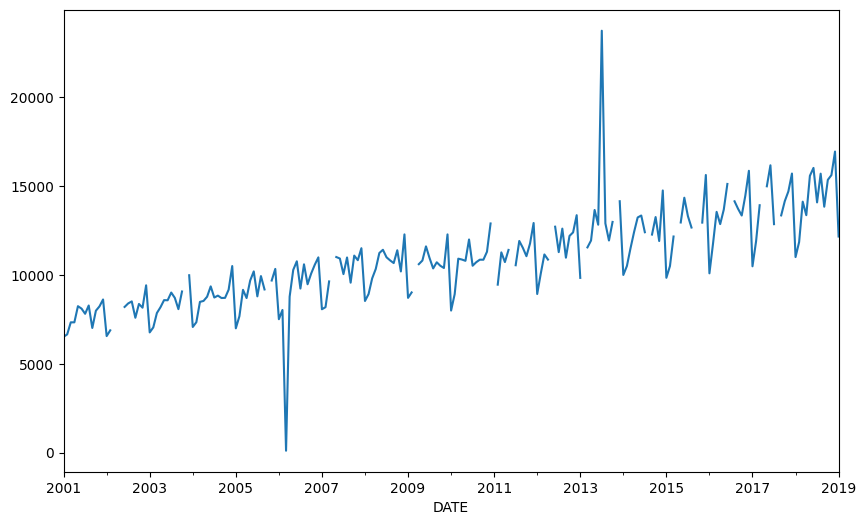

In [ ]:
plt.figure(figsize=(10, 6))
mobile_sales.Sales.plot()

# How many missing values

In [ ]:
mobile_sales.isna().sum()

,0
Sales,19


# Since there are only 19 nulls out of 200+ , can i just drop them?





# What are some ways you can think of to handle this?

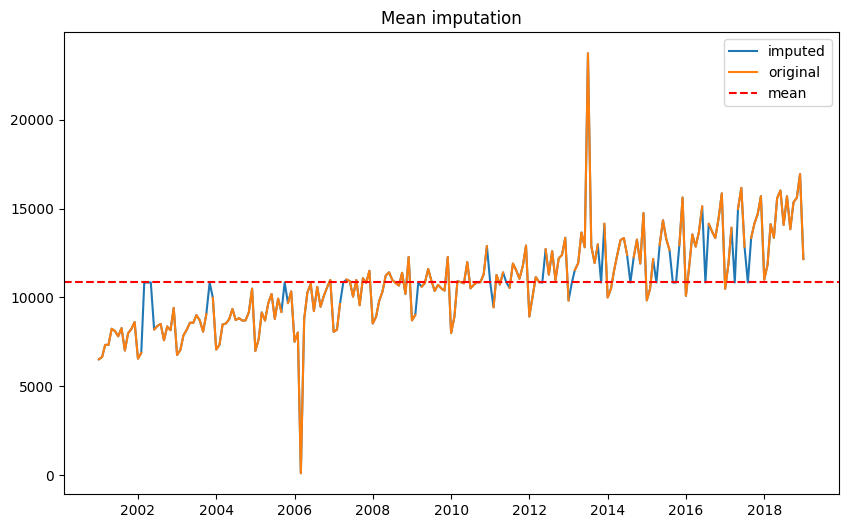

In [ ]:
mean_val = mobile_sales.Sales.mean()
plt.figure(figsize=(10, 6))
imputed = mobile_sales.Sales.fillna(mean_val)

plt.plot(mobile_sales.index, imputed, label='imputed')
plt.plot(mobile_sales.index, mobile_sales.Sales, label='original')

plt.axhline(mean_val, color='red', linestyle='--', label='mean')

plt.title('Mean imputation')
plt.legend()
plt.show()

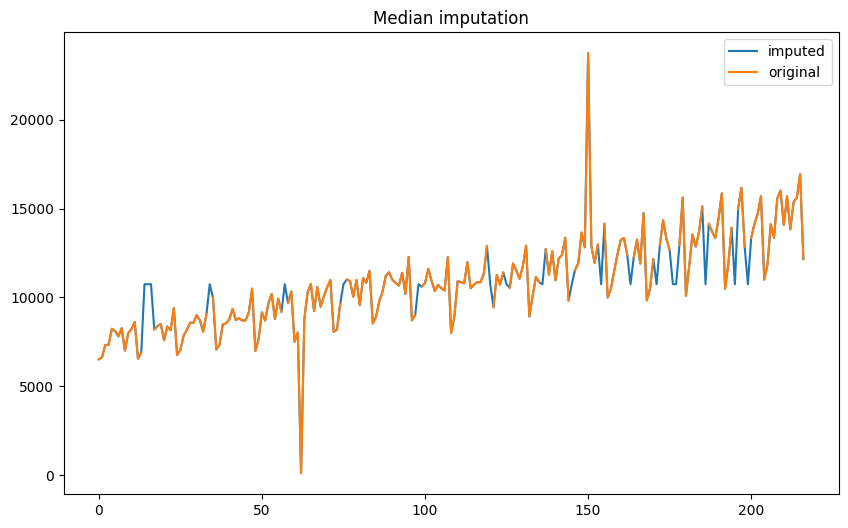

In [ ]:
plt.figure(figsize=(10, 6))
mobile_sales.Sales.fillna(mobile_sales.Sales.median()).plot(label='imputed')
mobile_sales.Sales.plot(label='original')
plt.title('Median imputation')
plt.legend()

# Interpolation

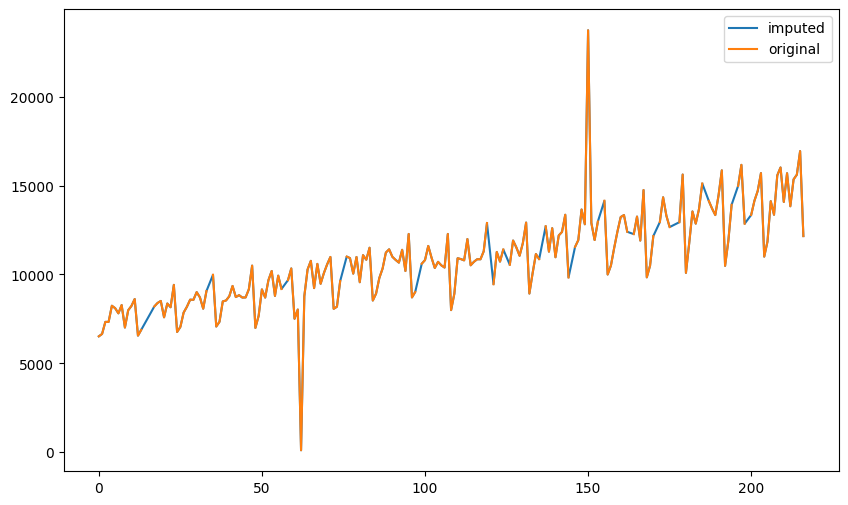

In [ ]:
plt.figure(figsize=(10, 6))
mobile_sales.Sales.interpolate(method='linear').plot(label='imputed')
mobile_sales.Sales.plot(label='original')
plt.legend()

In [ ]:
mobile_sales.Sales = mobile_sales.Sales.interpolate(method='linear')

In [ ]:
mobile_sales.isna().sum()

,0
Sales,0


# Handling Anomalies

[]

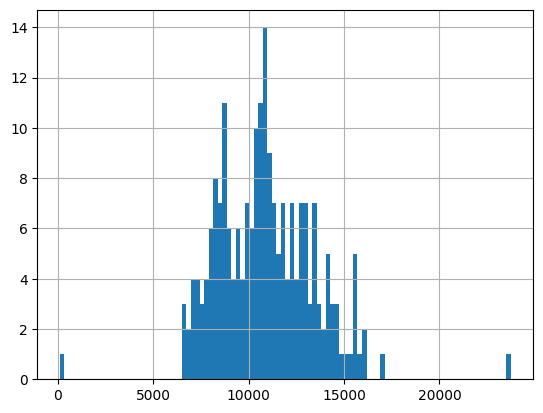

In [ ]:
mobile_sales.Sales.hist(bins=100).plot()

In [ ]:
mobile_sales.Sales.quantile(0.95)

np.float64(15164.599999999997)

In [ ]:
mobile_sales.Sales.quantile(0.05)

np.float64(7307.8)

<Axes: xlabel='DATE'>

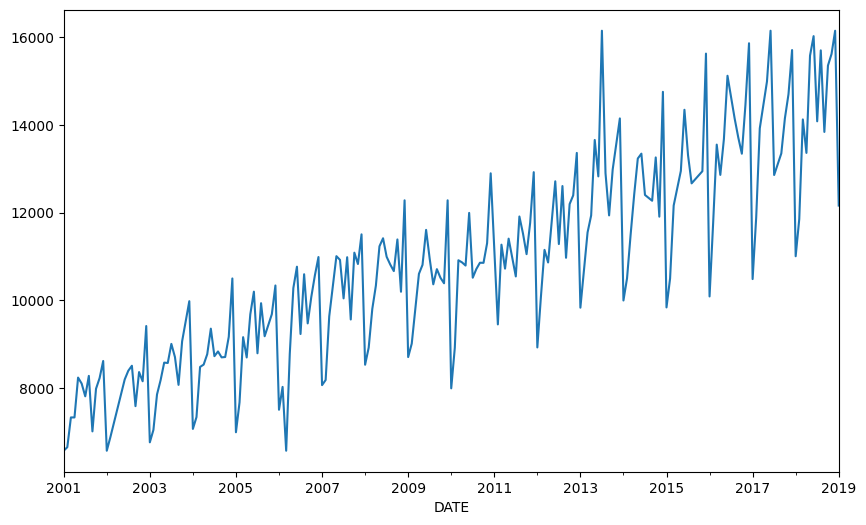

In [ ]:
plt.figure(figsize=(10, 6))
mobile_sales.Sales.clip(upper=mobile_sales.Sales.quantile(0.99), lower=mobile_sales.Sales.quantile(0.01)).plot()


In [ ]:
mobile_sales.Sales = mobile_sales.Sales.clip(upper=mobile_sales.Sales.quantile(0.95), lower=mobile_sales.Sales.quantile(0.05))

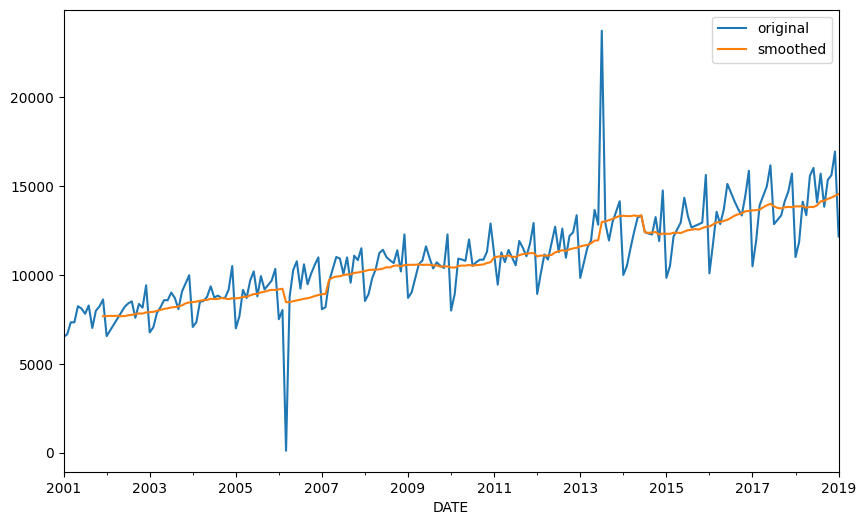

In [ ]:
plt.figure(figsize=(10, 6))
mobile_sales.Sales.plot(label='original')

# Plot data after implementing Moving Averages
mobile_sales.Sales.rolling(12).mean().plot(label='smoothed')

plt.legend()

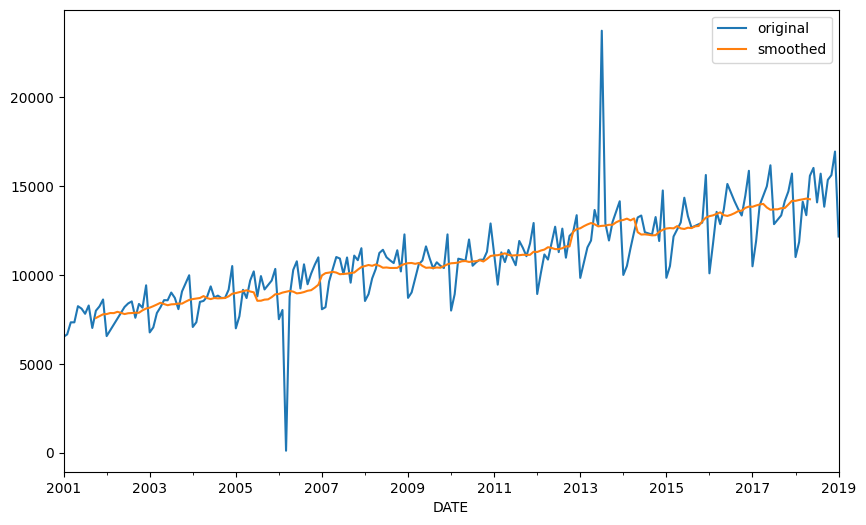

In [ ]:
plt.figure(figsize=(10, 6))
mobile_sales.Sales.plot(label='original')
mobile_sales.Sales.rolling(18, center=True).mean().plot(label='smoothed')
plt.legend()

In [ ]:
mobile_sales.to_csv('time_series_2_data.csv')